In [1]:
!pip install tensorflow opencv-python dlib matplotlib numpy

In [2]:
#PT1 - Face Alignment
# Step 1: Set Up Google Colab Environment
!apt-get update
!apt-get install -y cmake libboost-all-dev libopenblas-dev liblapack-dev libx11-dev libgtk-3-dev
!pip install dlib opencv-python tensorflow

import tensorflow as tf
import numpy as np
import cv2
import dlib
import matplotlib.pyplot as plt
import urllib.request
%matplotlib inline
print("Libraries installed and environment set up successfully.")

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:5 https://cli.github.com/packages stable InRelease
Get:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:7 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd64 Packages [5,691 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/multiverse amd64 Pack

In [3]:
# Step 2: Download the Facial Landmark Predictor Model
predictor_url = 'http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2'
urllib.request.urlretrieve(predictor_url, 'shape_predictor_68_face_landmarks.dat.bz2')

import bz2
with bz2.BZ2File('shape_predictor_68_face_landmarks.dat.bz2', 'rb') as f_in:
    with open('shape_predictor_68_face_landmarks.dat', 'wb') as f_out:
        f_out.write(f_in.read())
print("Facial landmark model downloaded and extracted.")

Facial landmark model downloaded and extracted.


In [5]:
from google.colab import files
uploaded = files.upload()

Saving FER2013_7emotions_Uniform_Augmented_Dataset.zip to FER2013_7emotions_Uniform_Augmented_Dataset.zip


In [6]:
import zipfile
zip_path = 'FER2013_7emotions_Uniform_Augmented_Dataset.zip'  # Adjust filename if needed
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')
print("Dataset unzipped to /content/dataset.")

train_dir = '/content/dataset/FER2013_7emotions_Uniform_Augmented_Dataset/train'
val_dir = '/content/dataset/FER2013_7emotions_Uniform_Augmented_Dataset/validation'
test_dir = '/content/dataset/FER2013_7emotions_Uniform_Augmented_Dataset/test'

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir, image_size=(48, 48), color_mode='grayscale', batch_size=32, label_mode='categorical'
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir, image_size=(48, 48), color_mode='grayscale', batch_size=32, label_mode='categorical'
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir, image_size=(48, 48), color_mode='grayscale', batch_size=32, label_mode='categorical'
)

class_names = train_ds.class_names
print("Class names:", class_names)
print("Train batches:", len(train_ds))

Dataset unzipped to /content/dataset.
Found 56000 files belonging to 7 classes.
Found 7000 files belonging to 7 classes.
Found 7000 files belonging to 7 classes.
Class names: ['Anger', 'Disgust', 'Fear', 'Happiness', 'Neutral', 'Sadness', 'Surprise']
Train batches: 1750


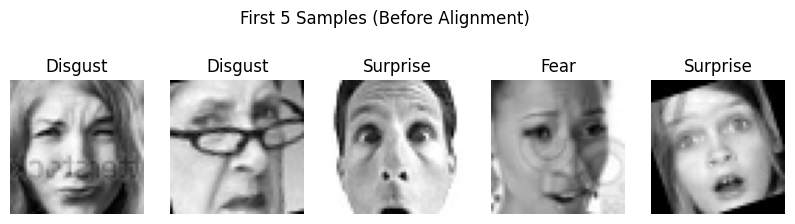

In [7]:
# Step 4: Display the First Few Samples of the Data
for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 5))
    for i in range(5):
        plt.subplot(2, 5, i+1)
        plt.imshow(images[i].numpy().squeeze(), cmap='gray')
        plt.title(class_names[np.argmax(labels[i])])
        plt.axis('off')
    plt.suptitle('First 5 Samples (Before Alignment)')
    plt.show()

In [8]:
# Step 5: Apply Face Alignment
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor('shape_predictor_68_face_landmarks.dat')

def align_face(image, label):
    img = (image.numpy() * 255).astype(np.uint8)  # Shape: (batch, 48, 48, 1)
    img = img[0] if img.ndim == 4 else img  # Ensure 3D or 2D array
    if img.shape[-1] == 1:  # If channel dimension exists
        img = img.squeeze()  # Remove channel to get (48, 48)
    else:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)  # Convert to RGB if needed (debug)

    print("Image shape:", img.shape, "dtype:", img.dtype)  # Debug print

    rects = detector(img, 1)
    if len(rects) == 0:
        return image, label  # Return original if no face

    landmarks = predictor(img, rects[0])

    left_eye = np.mean([(landmarks.part(i).x, landmarks.part(i).y) for i in range(36, 42)], axis=0)
    right_eye = np.mean([(landmarks.part(i).x, landmarks.part(i).y) for i in range(42, 48)], axis=0)

    dY = right_eye[1] - left_eye[1]
    dX = right_eye[0] - left_eye[0]
    angle = np.degrees(np.arctan2(dY, dX)) - 180

    center = (24, 24)  # 48x48 center
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(img, M, (48, 48))

    x, y, w, h = rects[0].left(), rects[0].top(), rects[0].width(), rects[0].height()
    center_x, center_y = x + w // 2, y + h // 2
    start_x = max(0, center_x - 24)
    start_y = max(0, center_y - 24)
    cropped = rotated[start_y:start_y+48, start_x:start_x+48]
    if cropped.shape != (48, 48):
        cropped = cv2.resize(cropped, (48, 48), interpolation=cv2.INTER_AREA)

    cropped = np.expand_dims(cropped, axis=-1) if cropped.ndim == 2 else cropped
    return tf.convert_to_tensor(cropped / 255.0, dtype=tf.float32), label

train_ds = train_ds.map(lambda img, lbl: tf.py_function(align_face, [img, lbl], [tf.float32, tf.float32]), num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(lambda img, lbl: tf.py_function(align_face, [img, lbl], [tf.float32, tf.float32]), num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.map(lambda img, lbl: tf.py_function(align_face, [img, lbl], [tf.float32, tf.float32]), num_parallel_calls=tf.data.AUTOTUNE)

train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

print("Face alignment applied to datasets.")

Face alignment applied to datasets.


Image shape: (48, 48) dtype: uint8
Image shape: (48, 48) dtype: uint8


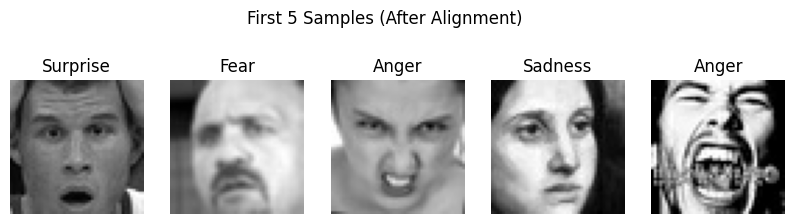

In [9]:
# Step 6: Verify the Alignment
for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 5))
    for i in range(5):
        plt.subplot(2, 5, i+1)
        plt.imshow(images[i].numpy().squeeze(), cmap='gray')
        plt.title(class_names[np.argmax(labels[i])])
        plt.axis('off')
    plt.suptitle('First 5 Samples (After Alignment)')
    plt.show()

In [12]:
# Ensure Google Drive is mounted
from google.colab import drive
drive.mount('/content/drive')

# Define save directory
save_dir = '/content/drive/My Drive/Colab Notebooks/aligned_fer2013'
import os
os.makedirs(save_dir, exist_ok=True)

# Save the preprocessed datasets
tf.data.experimental.save(train_ds, os.path.join(save_dir, 'train'))
tf.data.experimental.save(val_ds, os.path.join(save_dir, 'val'))
tf.data.experimental.save(test_ds, os.path.join(save_dir, 'test'))

print(f"Preprocessed datasets saved to {save_dir}.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Image shape: (48, 48) dtype: uint8
Image shape: (48, 48) dtype: uint8
Image shape: (48, 48) dtype: uint8
Image shape: (48, 48) dtype: uint8
Image shape: (48, 48) dtype: uint8
Image shape: (48, 48) dtype: uint8
Image shape: (48, 48) dtype: uint8
Image shape: (48, 48) dtype: uint8
Image shape: (48, 48) dtype: uint8
Image shape: (48, 48) dtype: uint8
Image shape: (48, 48) dtype: uint8
Image shape: (48, 48) dtype: uint8
Image shape: (48, 48) dtype: uint8
Image shape: (48, 48) dtype: uint8
Image shape: (48, 48) dtype: uint8
Image shape: (48, 48) dtype: uint8
Image shape: (48, 48) dtype: uint8
Image shape: (48, 48) dtype: uint8
Image shape: (48, 48) dtype: uint8
Image shape: (48, 48) dtype: uint8
Image shape: (48, 48) dtype: uint8
Image shape: (48, 48) dtype: uint8
Image shape: (48, 48) dtype: uint8
Image shape: (48, 48) dtype: uint8
Image shape: (48, 48) dtype: ui